### Helpers

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ==============================================================================
#  CONFIGURATION: DATA MAPPING
# ==============================================================================
# Define the column names here. 
# The script will use the first column name found in the CSVs.
# ==============================================================================

COLUMN_MAPPING_OptiAbt = {
    # System Columns
    'time':       ['time'],
    'modus':      ['modus_val', 'modus'],

    # Inputs (Blue)
    'n_fan':      ['VD_n2'],                                  # Will be * 60
    'T_in':       ['TempKK'],
    'rh_in':      ['KK_rlFeuchteKK', 'rlFeuchteKK'],
    'm_ref':      ['MSS_rMassenstrom'],                       # Will be / 1000
    'p_ref_in':   ['VD_p_out'],
    'h_ref_in':   ['VD_h_in_korr', 'VD_isenthalp_h_in'],

    # Outputs (Red)
    'h_ref_out':  ['VD_h_out'],
    'dp':         ['Delta_P_VD'],
    
    # Special Handling for Frost Mass
    'mass_raw':   ['WAAGEN_Waage1_Masse_smooth', 'WAAGEN_Waage2_Masse']
}



COLUMN_MAPPING_ObtiHorst = {
    # System Columns
    'time':       ['time'], 
    'modus':      ['modus_val'],

    # Inputs (Blue)
    'n_fan':      ['StateMachine_rps_EvapFan'], # Will be * 60
    'T_in':       ['KK_Temp_KK'],
    'rh_in':      ['KK_rlFeuchte_KK'],
    'm_ref':      ['StateMachine_m_CompOut'],
    'p_ref_in':   ['StateMachine_p_EvapOut'],
    'h_ref_in':   ['StateMachine_h_EvapIn'],

    # Outputs (Red)
    'h_ref_out':  ['StateMachine_h_EvapOut'],
    'dp':         ['StateMachine_p_PresLos'],
    'mass_raw':   ['WAAGEN_Waage1_Masse_smooth', 'WAAGEN_Waage2_Masse']
}

# ==============================================================================
#  HELPER FUNCTIONS
# ==============================================================================

def get_data_col(df_main, df_kk, key_name):
    """
    Searches for the column defined in COLUMN_MAPPING in df_main, then df_kk.
    Returns the values if found, else None.
    """
    possible_names = COLUMN_MAPPING.get(key_name, [])
    
    for col in possible_names:
        if col in df_main.columns:
            return df_main[col]
        if col in df_kk.columns:
            return df_kk[col]
    return None

# ==============================================================================
#  MAIN PLOTTING FUNCTION
# ==============================================================================

def plot_experiments_simple(experiment_ids, path_exp, experiment_name, save_fig=False, group_name=None):
    """
    Unified Dashboard: Supports both Standard and OptiHorst Data formats.
    """
    
    # 0. COLORS
    BLUE_GRADIENT = ['#89CFF0', '#4682B4', '#0047AB', '#000080', '#04043A']
    RED_GRADIENT  = ['#FFB3B3', '#FF8080', '#FF4D4D', '#E60000', '#8B0000']

    if experiment_name == "OptiHorst":
        COLUMN_MAPPING = COLUMN_MAPPING_ObtiHorst
    elif experiment_name == "OptiAbt":
        COLUMN_MAPPING = COLUMN_MAPPING_OptiAbt
    else:
        raise ValueError("experiment_name must be either 'OptiHorst' or 'OptiAbt'.")
    
    if len(experiment_ids) > 5:
        raise ValueError("Maximum 5 experiments allowed.")

    # 1. LOAD DATA
    experiments = []
    max_time = 0.0

    print(f"--- Processing {len(experiment_ids)} Experiments ---")

    for exp_id in experiment_ids:
        entry = {'id': exp_id, 'avail': False, 'time': None, 'data': {}}
        try:
            f_data = os.path.join(path_exp, f"{exp_id}_data.csv")
            f_kk = os.path.join(path_exp, f"{exp_id}_data_KK.csv")

            # Check files
            if os.path.exists(f_data):
                # Load CSVs
                df = pd.read_csv(f_data, sep=';', decimal='.', on_bad_lines='skip', low_memory=False)
                
                # Load KK if exists, else empty
                if os.path.exists(f_kk):
                    df_kk = pd.read_csv(f_kk, sep=';', decimal='.', low_memory=False)
                else:
                    df_kk = pd.DataFrame(index=df.index)

                # ==========================================================
                # NEW: LOGIC TO CALCULATE MODUS (OPTIHORST)
                # ==========================================================
                # Try to find explicit modus column
                modus_series = get_data_col(df, df_kk, 'modus')
                
                # If explicit modus missing, calculate from Fan Speed (OptiHorst Logic)
                if modus_series is None:
                    print(f"[{exp_id}] No 'modus' column. Calculating from Fan RPM...")
                    # Get raw fan speed (check both columns)
                    raw_n = get_data_col(df, df_kk, 'n_fan')
                    
                    if raw_n is not None:
                        # Convert to numeric just in case
                        fan_vals = pd.to_numeric(raw_n, errors='coerce').fillna(0)
                        # Assume RPS if small, RPM if large, or just check > 1
                        # OptiHorst logic: Check if running (>1)
                        is_running = fan_vals > 1
                        
                        # Find longest continuous group
                        group_ids = (is_running != is_running.shift()).cumsum()
                        if is_running.any():
                            active_groups = group_ids[is_running]
                            longest_group = active_groups.value_counts().idxmax()
                            modus_series = (group_ids == longest_group).astype(int)
                            valid_indices = modus_series[modus_series == 1].index
                            modus_series.loc[valid_indices[:10]] = 0  # Cut Start
                            modus_series.loc[valid_indices[-10:]] = 0 # Cut End
                        else:
                            modus_series = pd.Series(0, index=df.index)
                    else:
                        # No fan data, take everything
                        modus_series = pd.Series(1, index=df.index)


                # ==========================================================
                # FILTERING
                # ==========================================================
                mask = modus_series == 1
                valid = df.index[mask]
                
                # Intersect if df_kk exists
                if not df_kk.empty:
                    valid = valid.intersection(df_kk.index)
                
                df = df.loc[valid]
                if not df_kk.empty:
                    df_kk = df_kk.loc[valid]

                if not df.empty:
                    # ==========================================================
                    # TIME HANDLING (Fix for missing Time column)
                    # ==========================================================
                    t_raw = get_data_col(df, df_kk, 'time')
                    
                    if t_raw is not None:
                        # Standard Case: Column exists
                        t_arr = pd.to_numeric(t_raw, errors='coerce').values
                    else:
                        # Fallback: Use Index (Assuming 1Hz sampling -> seconds)
                        print(f"[{exp_id}] No 'time' column. Using Index.")
                        t_arr = df.index.values * 1.0

                    # Normalize to start at 0 and convert to Minutes
                    t_exp = (t_arr - t_arr[0]) / 60.0
                    entry['time'] = t_exp
                    max_time = max(max_time, t_exp[-1] if len(t_exp) > 0 else 0)

                    # ==========================================================
                    # DATA EXTRACTION & UNIT CORRECTION
                    # ==========================================================
                    d = {}
                    
                    # 1. Inputs
                    val_n = get_data_col(df, df_kk, 'n_fan')
                    d['n_fan'] = val_n.values * 60.0 if val_n is not None else np.zeros(len(df))
                    
                    val_T = get_data_col(df, df_kk, 'T_in')
                    d['T_in'] = val_T.values if val_T is not None else np.zeros(len(df))
                    
                    val_rh = get_data_col(df, df_kk, 'rh_in')
                    d['rh_in'] = val_rh.values if val_rh is not None else np.zeros(len(df))

                    # MASS FLOW Handling
                    # Standard data is often g/s (needs /1000). OptiHorst is kg/s.
                    val_m = get_data_col(df, df_kk, 'm_ref')
                    if val_m is not None:
                        m_vals = val_m.values
                        # Heuristic: If mean is < 1, it's likely already kg/s. 
                        # If mean > 1, it's likely g/s.
                        if np.mean(m_vals) < 0.5: 
                            d['m_ref'] = m_vals # Already kg/s
                        else:
                            d['m_ref'] = m_vals / 1000.0 # Convert g/s to kg/s
                    else:
                        d['m_ref'] = np.zeros(len(df))

                    val_p_in = get_data_col(df, df_kk, 'p_ref_in')
                    d['p_ref_in'] = val_p_in.values if val_p_in is not None else np.zeros(len(df))

                    val_h_in = get_data_col(df, df_kk, 'h_ref_in')
                    d['h_ref_in'] = val_h_in.values if val_h_in is not None else np.zeros(len(df))

                    # 2. Outputs
                    val_h_out = get_data_col(df, df_kk, 'h_ref_out')
                    d['h_ref_out'] = val_h_out.values if val_h_out is not None else np.zeros(len(df))

                    val_dp = get_data_col(df, df_kk, 'dp')
                    d['dp'] = val_dp.values if val_dp is not None else np.zeros(len(df))
                    
                    # 3. Calculated Outputs
                    # Heat Flow Q = m_dot * delta_h
                    # Check dimensions: kg/s * kJ/kg = kW
                    q_kw = d['m_ref'] * (d['h_ref_out'] - d['h_ref_in'])
                    d['Q'] = q_kw * 1000.0 # Convert to Watts for plot
                    
                    # Frost Mass
                    val_mass_raw = get_data_col(df, df_kk, 'mass_raw')
                    if val_mass_raw is not None:
                        m_raw = pd.to_numeric(val_mass_raw, errors='coerce').interpolate().bfill().values
                        d['m_frost'] = (m_raw - np.min(m_raw)) * 1000.0 # kg to g
                    else:
                        d['m_frost'] = np.zeros(len(df))

                    entry['data'] = d
                    entry['avail'] = True
            else:
                print(f"[{exp_id}] File not found.")

        except Exception as e:
            print(f"Error loading {exp_id}: {e}")
            import traceback
            traceback.print_exc()
        
        experiments.append(entry)

    # 2. PLOTTING (NO CHANGES NEEDED HERE, same as before)
    fig = plt.figure(figsize=(24, 13))
    
    title_text = f"Dashboard: {group_name}" if group_name else f"Dashboard: {len(experiment_ids)} Experiments"
    fig.suptitle(title_text, fontsize=20, fontweight='bold', y=0.96)

    # Grids: Top (Inputs), Bottom (Outputs)
    gs_top = gridspec.GridSpec(2, 3, figure=fig, top=0.90, bottom=0.45, hspace=0.35, wspace=0.20)
    gs_bot = gridspec.GridSpec(1, 4, figure=fig, top=0.38, bottom=0.05, hspace=0.0, wspace=0.20)

    # Input Map
    inputs = [
        (0, 0, 'n_fan', 'Fan Speed [rpm]'), (0, 1, 'T_in', 'Air Inlet Temp [°C]'), (0, 2, 'rh_in', 'Air Inlet RH [%]'),
        (1, 0, 'm_ref', 'Ref. Mass Flow [kg/s]'), (1, 1, 'h_ref_in', 'Ref. In Enthalpy [kJ/kg]'), (1, 2, 'p_ref_in', 'Evap. In Pressure [bar]')
    ]

    # Output Map
    outputs = [
        (0, 'dp', 'Pressure Drop [Pa]'), (1, 'h_ref_out', 'Ref. Out Enthalpy [kJ/kg]'),
        (2, 'Q', 'Heat Flow [W]'), (3, 'm_frost', 'Frost Mass [g]')
    ]

    # --- Plot Inputs ---
    for r, c, key, title in inputs:
        ax = fig.add_subplot(gs_top[r, c])
        for idx, exp in enumerate(experiments):
            if exp['avail'] and key in exp['data']:
                label = f"Exp {exp['id']}" if (r==0 and c==0) else ""
                ax.plot(exp['time'], exp['data'][key], color=BLUE_GRADIENT[idx], lw=1.5, alpha=0.8, label=label)
        
        ax.set_title(title, fontsize=11, fontweight='bold', color='#333333')
        ax.grid(True, linestyle=':', alpha=0.6)
        ax.set_xlim(0, max_time)
        if r==0 and c==0: ax.legend(loc='best')

    # --- Plot Outputs ---
    for c, key, title in outputs:
        ax = fig.add_subplot(gs_bot[0, c])
        for idx, exp in enumerate(experiments):
            if exp['avail'] and key in exp['data']:
                ax.plot(exp['time'], exp['data'][key], color=RED_GRADIENT[idx], lw=1.5, alpha=0.8)

        ax.set_title(title, fontsize=11, fontweight='bold', color='#333333')
        ax.set_xlabel("Time [min]")
        ax.grid(True, linestyle=':', alpha=0.6)
        ax.set_xlim(0, max_time)

    # 3. SAVE / SHOW
    if save_fig:
        name_clean = str(group_name or f"{len(experiment_ids)}_Exp").replace(" ", "_")
        out_path = os.path.join(path_exp, "graphics", "Final_Comparison", f"Dashboard_{name_clean}.png")
        os.makedirs(os.path.dirname(out_path), exist_ok=True)
        plt.savefig(out_path, dpi=300)
        plt.close()
    else:
        plt.show()

In [ ]:
from pathlib import Path

# experiment_ids = [1,2,3,4,5]
# path_exp = Path(r"D:\mbc_nba\OptiAbt_Daten\Versuche\CSV_Export")

path_exp = Path(r"D:\mbc_nba\OptiHorst\Daten\Abtauen\CSV_Export")


experiment_groups = {
    "+6°C": [96,97,119,120,121],
    "-1°C": [25,26,27,64,28],
    "-3°C": [44,45,46,75,85],
    "-5°C": [106,107,108,125,126],
    "-10°C": [60,61,62,83,84],

    # ALTERNATIVES
    # "+6°C (Version 2)": [12,13,15,71],
    # "+6°C (Version 3)": [87,89,92,100],
    # "-1°C (Version 2)": [65,29,30,31],
    # "-3°C (Version 2)": [33,34,35,36,63],
    # "-5°C (Version 2)": [57,108,109,110],
    # "-5°C (Version 3)": [77,124,127,78,105],
    # "-10°C (Version 2)": [51,52],


}


# 2. Iterate through each group
for group_name, experiment_ids in experiment_groups.items():
    plot_experiments_simple(experiment_ids, path_exp, experiment_name="OptiHorst", save_fig=False, group_name=group_name)


### Simulation

Model initialized with fluid: R134a

Processing Group: +0 °C
IDs: [40, 41, 42, 43, 44]
--- Aggregating Data (OptiAbt) for Experiments: [40, 41, 42, 43, 44] ---


d:\mbc_nba\vclibpy\frost_evaporator_nba\frost_evaporator\physics\fan_system_model.py:220: UserWarning: [Wang Correlation Validity] Transverse Pitch (Pt) value 50.00 is outside the valid range [17.7 - 31.75]. Results may be inaccurate.
  warnings.warn(


--- Simulation of Experiment Combined_5_OptiAbt ---
--- Initializing Model ---


--- Starting Simulation ---


Sim Combined_5_OptiAbt: 100%|██████████| 20/20 [00:22<00:00,  1.14s/it]


--- Visualizing 5 Experiments (OptiAbt) ---


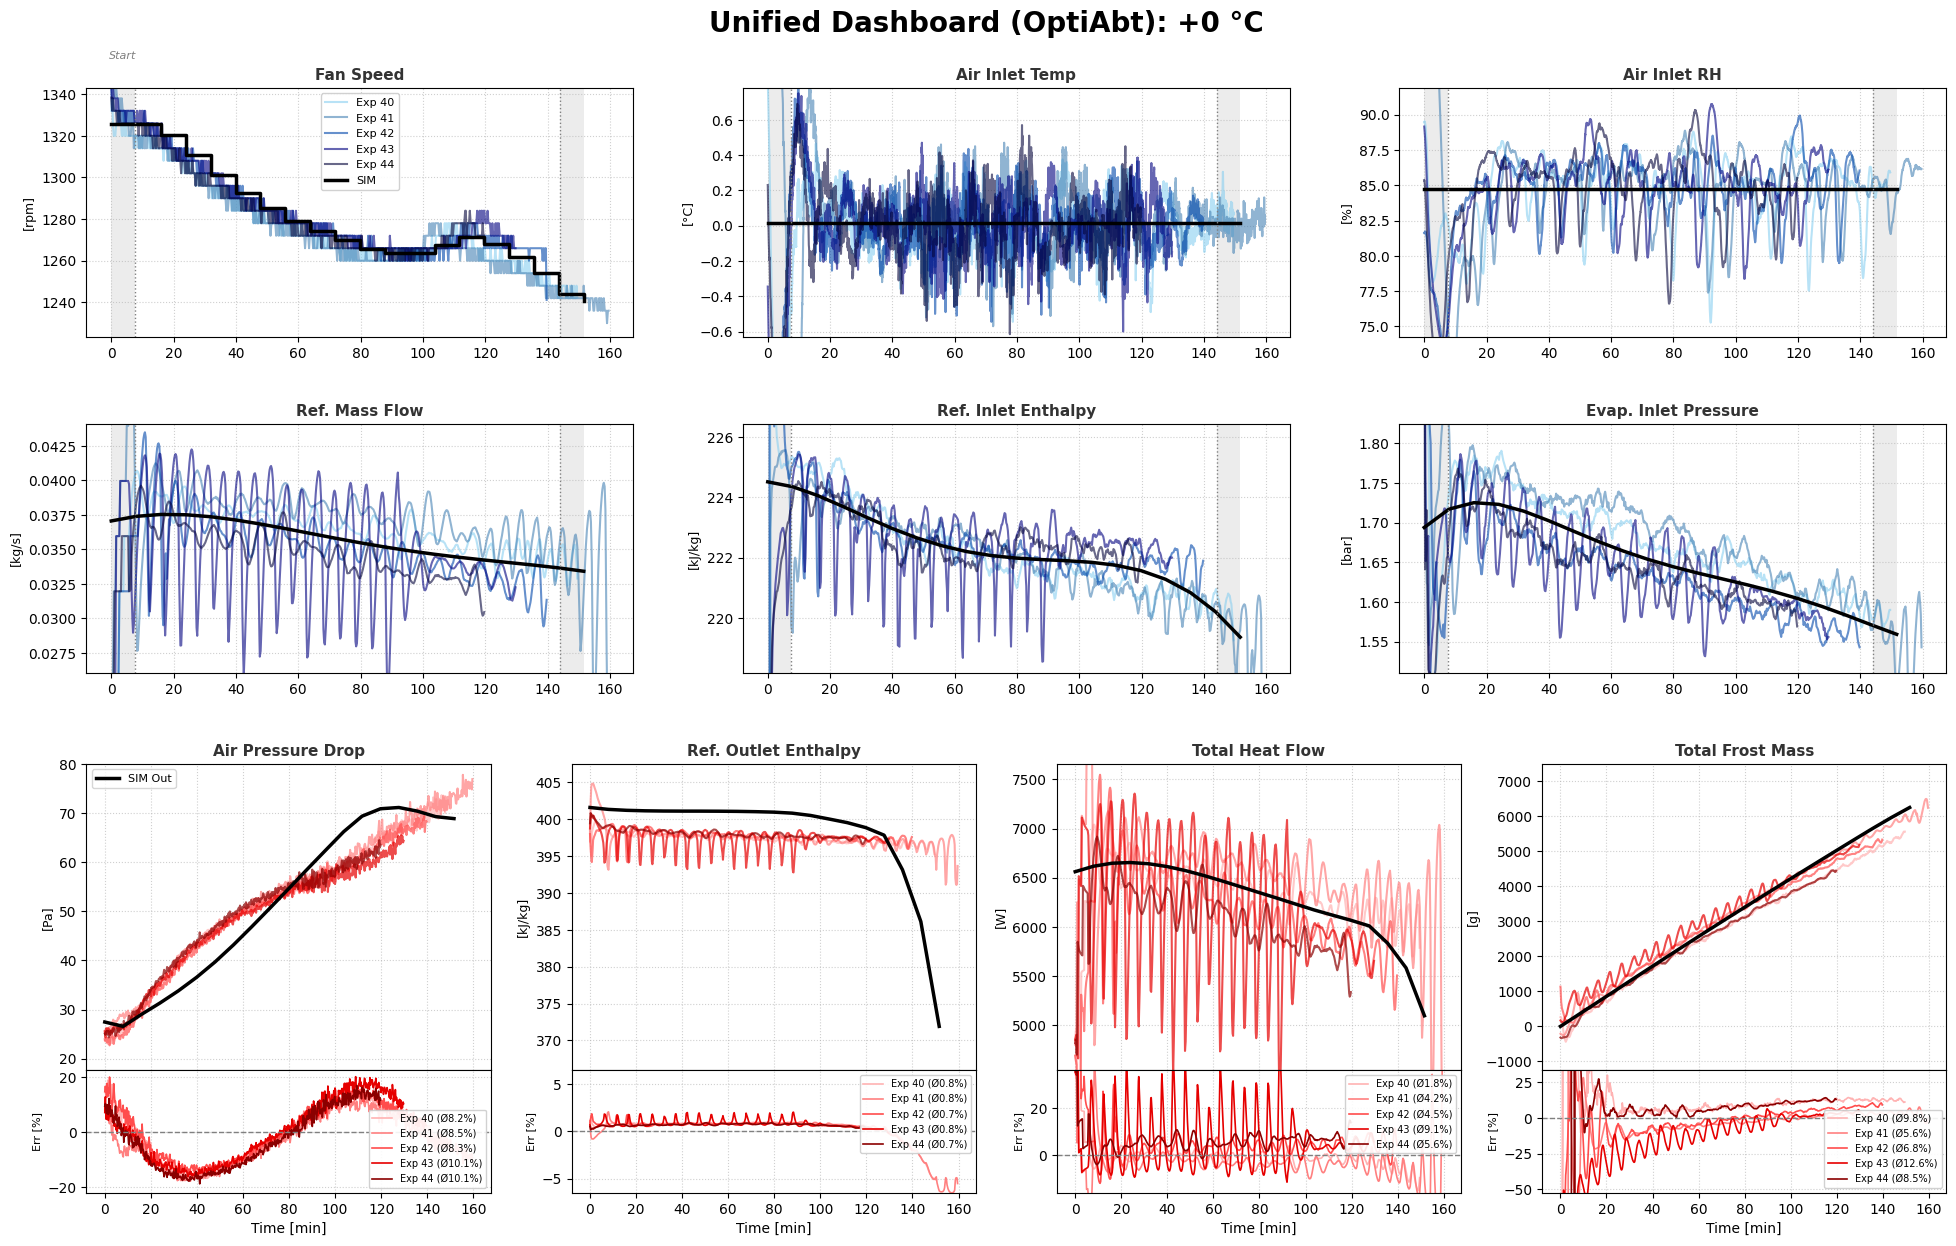


Processing Group: -7 °C
IDs: [27, 28, 29, 30]
--- Aggregating Data (OptiAbt) for Experiments: [27, 28, 29, 30] ---
--- Simulation of Experiment Combined_4_OptiAbt ---
--- Initializing Model ---


--- Starting Simulation ---


Sim Combined_4_OptiAbt: 100%|██████████| 20/20 [00:15<00:00,  1.27it/s]


--- Visualizing 4 Experiments (OptiAbt) ---


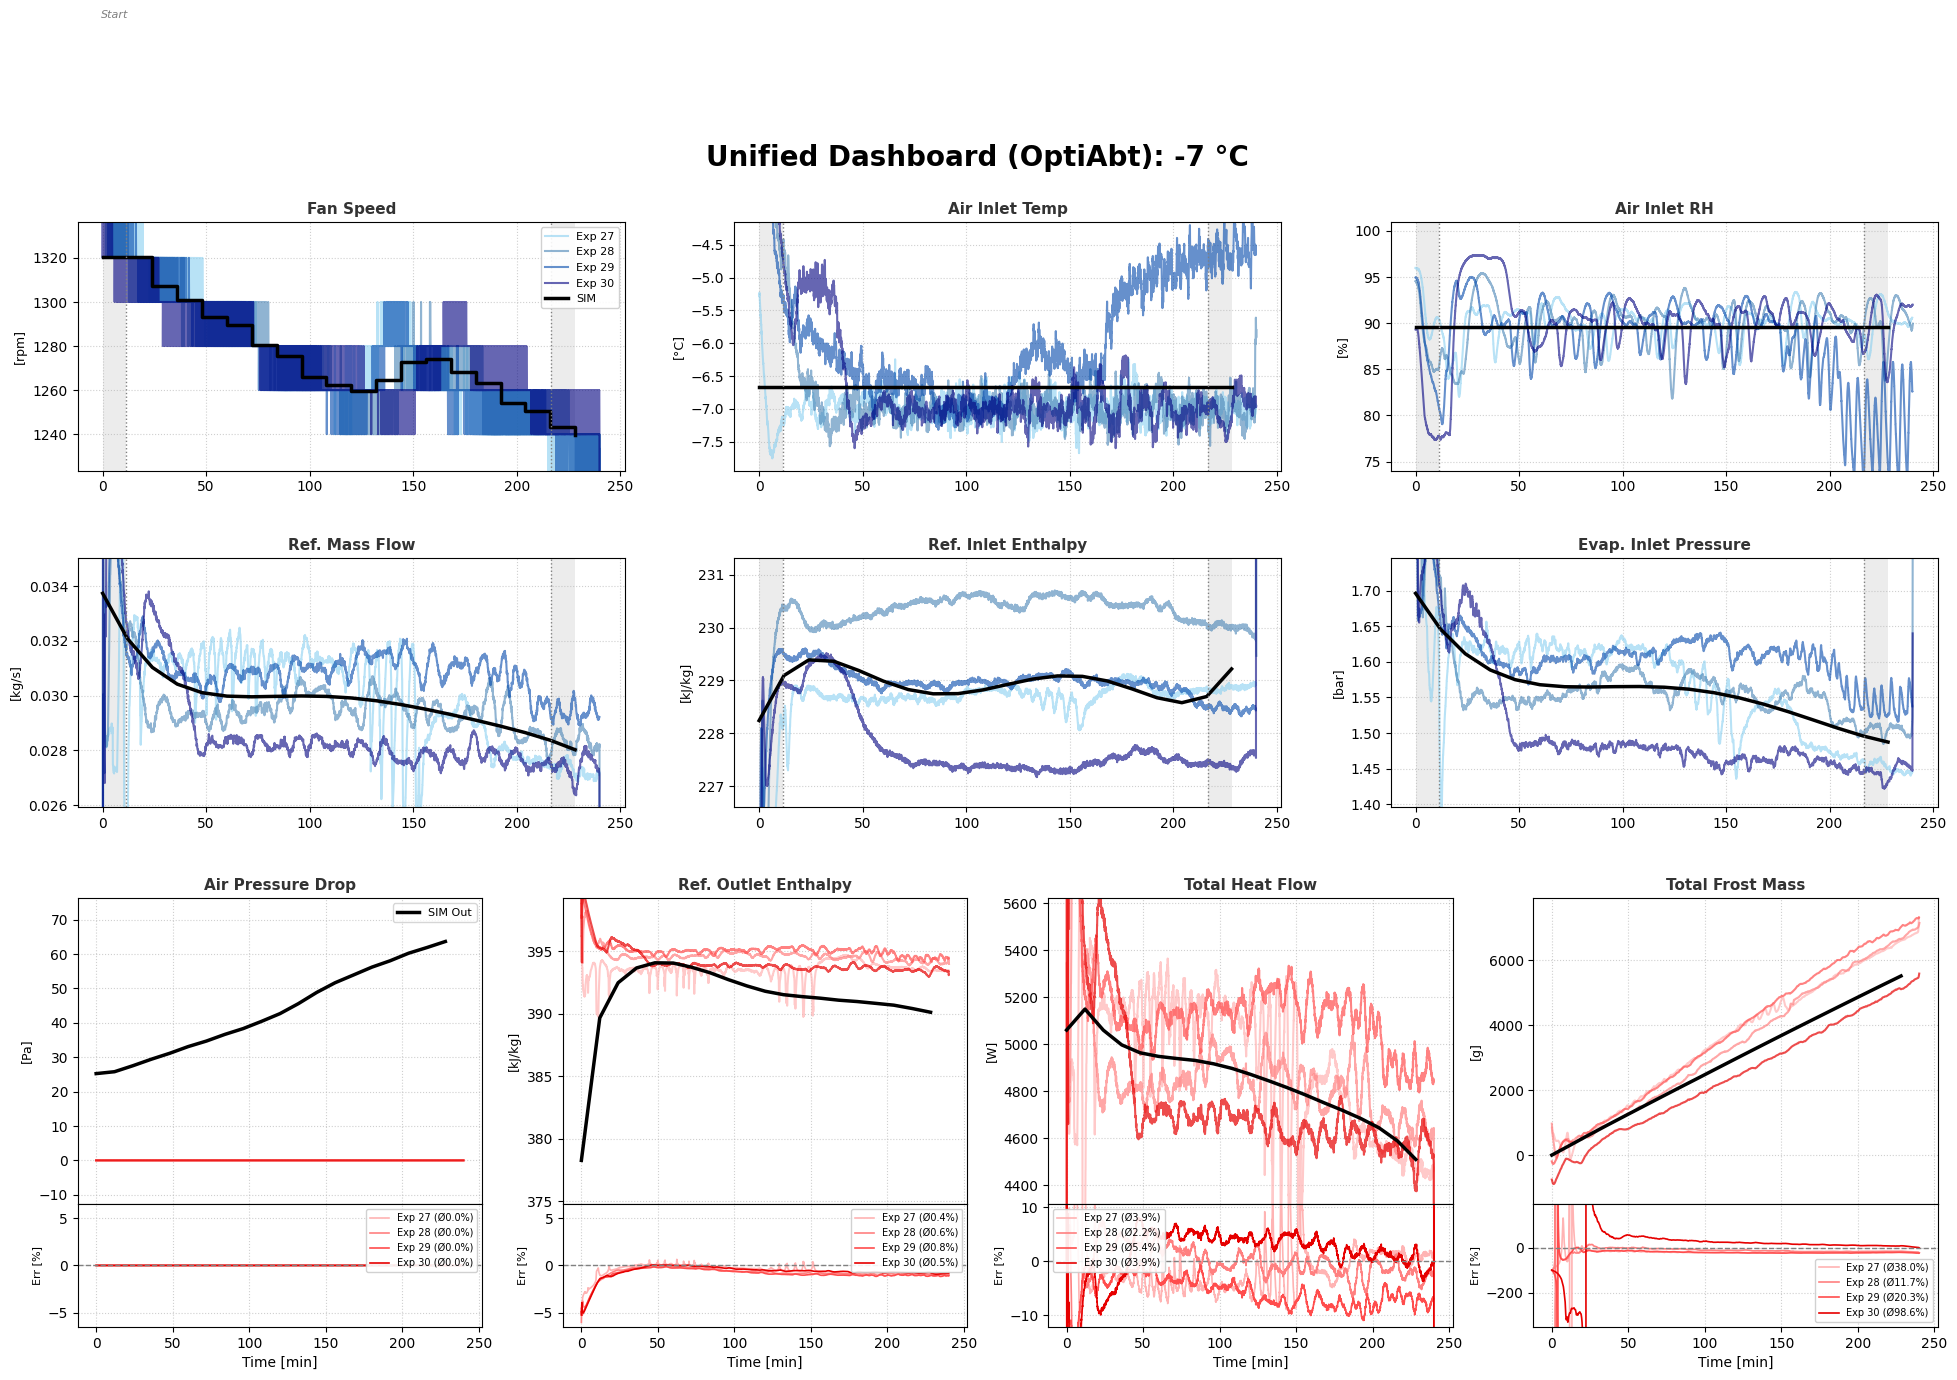


Processing Group: -12 °C
IDs: [13, 18]
--- Aggregating Data (OptiAbt) for Experiments: [13, 18] ---
--- Simulation of Experiment Combined_2_OptiAbt ---
--- Initializing Model ---


--- Starting Simulation ---


Sim Combined_2_OptiAbt: 100%|██████████| 20/20 [00:08<00:00,  2.28it/s]


--- Visualizing 2 Experiments (OptiAbt) ---


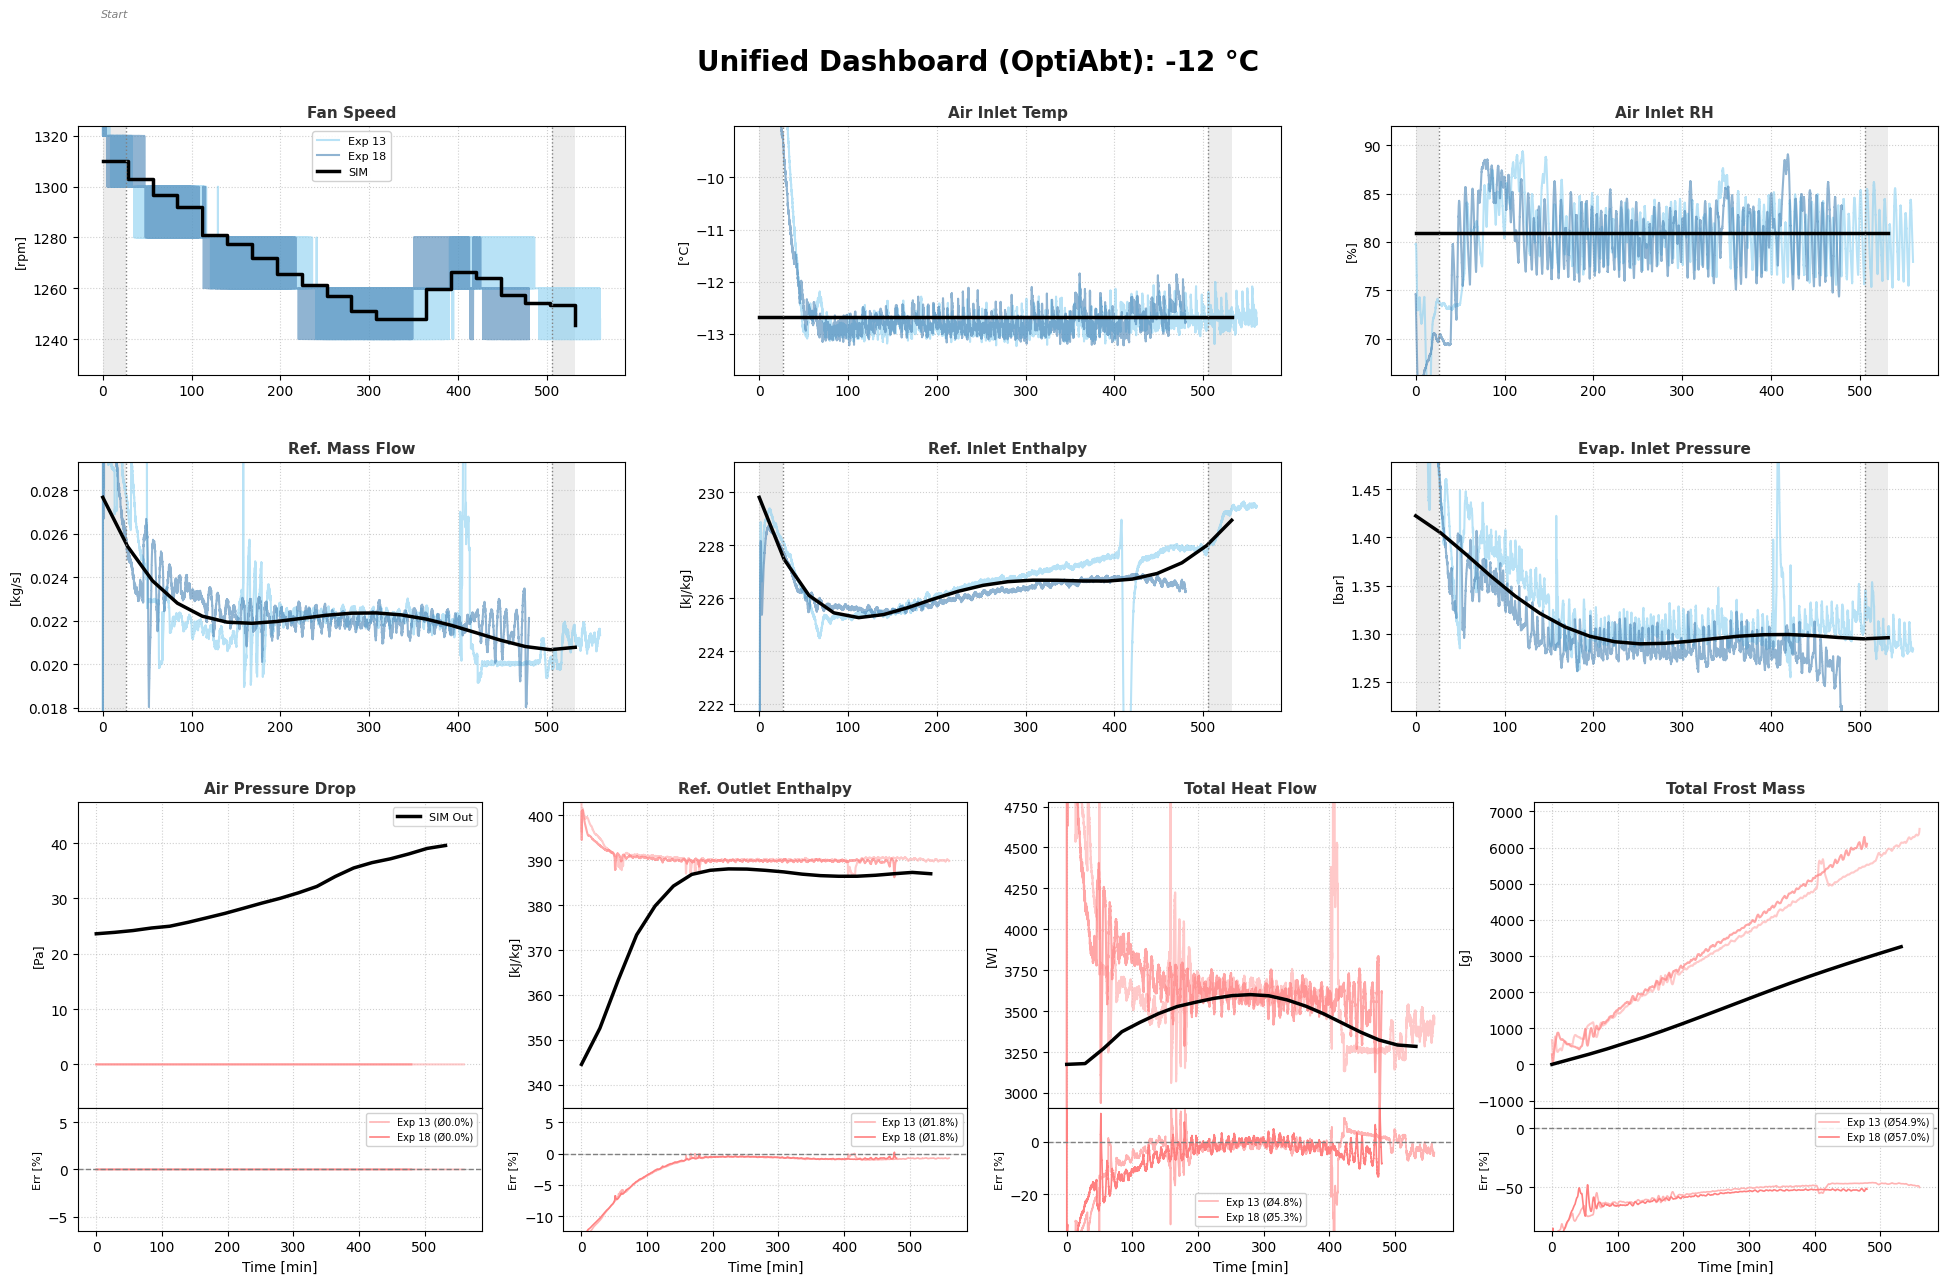

In [2]:
from pathlib import Path
import sys
import os

project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.append(project_root)

from frost_evaporator import MultiExperimentAnalyzer, FrostEvaporatorSimulation, SimulationVisualizer


##############################################################################################
# Opti Abt
##############################################################################################

path_exp_abt = Path(r"D:\mbc_nba\OptiAbt_Daten\Versuche\CSV_Export")
experiment_groups_abt = {
    "+0 °C":  [40, 41, 42, 43, 44],
    "-7 °C":  [27, 28, 29, 30],
    "-12 °C": [13, 18],


    # ALTERNATIVES
    # "+0 °C (Version 1)":  [3, 4, 5, 7, 8],
    # "+0 °C (Version 2)":  [9, 10, 11, 16, 20],
    # "+0 °C (Version 3)":  [20, 22, 23, 25, 36],
    # "+0 °C (Version 4)":  [45, 46, 47, 48, 49],

    # "-12 °C (Full Version)": [13, 18, 26],


    # "+3 °C":  [52, 53, 55, 56, 67],
}


# experiment_groups_abt = {
#     "Abt-a":  [40],
#     "Abt-b":  [28],
#     "Abt-c":  [13],
# }




analyzer_abt = MultiExperimentAnalyzer(experiment_type='OptiAbt')
sim_abt = FrostEvaporatorSimulation("config_OptiAbt.yaml")
viz_abt = SimulationVisualizer(sim_abt.params)

cutoff_pct = 0.05


for group_name, experiment_ids in experiment_groups_abt.items():
    
    print(f"\n{'='*40}")
    print(f"Processing Group: {group_name}")
    print(f"IDs: {experiment_ids}")
    print(f"{'='*40}")

    try:
        # Run analysis
        exp_data = analyzer_abt.analyze(
            exp_ids=experiment_ids, 
            data_path=path_exp_abt, 
            cutoff_pct=cutoff_pct, 
            time_step=sim_abt.params.time_step
        )

        # Run Simulation
        states_history, inputs_history = sim_abt.run(exp_data)

        # Plot 
        viz_abt.plot_comparison(states_history, inputs_history, experiment_ids, path_exp_abt, cutoff_pct, save_fig=False, group_name=group_name, experiment_name="OptiAbt")
        # print(viz_abt.get_relative_error_table(states_history, inputs_history, experiment_ids, path_exp_abt, cutoff_pct, experiment_name="OptiAbt"))
        # viz_abt.plot_layer_temperatures(states_history)
        # viz_abt.plot_detailed(states_history, inputs_history, experiment_ids)
        # viz_abt.plot_roughness(states_history, experiment_ids[0])
        # viz_abt.plot_frost_distribution(states_history)
        # viz_abt.plot_debug(states_history, inputs_history, experiment_ids[0])

    except Exception as e:
        import traceback
        print(f"!!! CRITICAL FAILURE in Group {group_name} !!!")
        print(f"Error Message: {e}")
        traceback.print_exc()

###############################################################################################
# Opti Horst
###############################################################################################

# path_exp_horst = Path(r"D:\mbc_nba\OptiHorst\Daten\Abtauen\CSV_Export")
# experiment_groups_horst = {
#     "-1°C":  [25,26,27,64,28],
#     "-3°C":  [44,45,46,75],
#     # "-5°C":  [78,102,103,104],
#     # "-10°C": [60,61,62,83,84],

#     # Alternatives
#     # "-1°C (Version 2)":  [65,29,30,31],
#     # "-3°C (Version 2)":  [34,35,36,63],
#     # "-5°C (Version 2)":  [56,77,115],
#     # "-10°C (Version 2)": [51,52],


#     # Non Frost:
#     # "+6°C":              [96,97,119,120,121],
#     # "+6°C (Version 2)":  [12,13,15,71],
#     # "+6°C (Version 3)":  [87,89,92,100],
# }
# # experiment_groups_horst = {
# #     "Horst-a":  [64],
# #     "Horst-b":  [60],
# # }
# # experiment_groups_horst = {
# #     "Horst-a":  [64],
# #     "Horst-b":  [102],
# # }

# analyzer_horst = MultiExperimentAnalyzer(experiment_type='OptiHorst')
# sim_horst      = FrostEvaporatorSimulation("config_OptiHorst.yaml")
# viz_horst      = SimulationVisualizer(sim_horst.params)

# cutoff_pct = 0.05


# for group_name, experiment_ids in experiment_groups_horst.items():
    
#     print(f"\n{'='*40}")
#     print(f"Processing Group: {group_name}")
#     print(f"IDs: {experiment_ids}")
#     print(f"{'='*40}")

#     try:
#         # Run analysis
#         exp_data = analyzer_horst.analyze(
#             exp_ids=experiment_ids, 
#             data_path=path_exp_horst, 
#             cutoff_pct=cutoff_pct, 
#             time_step=sim_horst.params.time_step
#         )

#         # Run Simulation
#         states_history, inputs_history = sim_horst.run(exp_data)

#         # Plot 
#         viz_horst.plot_comparison(states_history, inputs_history, experiment_ids, path_exp_horst, cutoff_pct, save_fig=True, group_name=group_name, experiment_name="OptiHorst")
#         # print(viz_horst.get_relative_error_table(states_history, inputs_history, experiment_ids, path_exp_horst, cutoff_pct, experiment_name="OptiHorst"))
#         viz_horst.plot_layer_temperatures(states_history)
#         # viz_horst.plot_heat_transfer_coefficients(states_history)
#         # viz_horst.plot_detailed(states_history, inputs_history, experiment_ids)
#         viz_horst.plot_roughness(states_history, experiment_ids[0])
#         # viz_horst.plot_frost_distribution(states_history)
#         viz_horst.plot_debug(states_history, inputs_history, experiment_ids[0])
        

#     except Exception as e:
#         import traceback
#         print(f"!!! CRITICAL FAILURE in Group {group_name} !!!")
#         print(f"Error Message: {e}")
#         traceback.print_exc()



<!-- ### Run Mutliple Simulations -->

### Parameter Optimierung

In [2]:
from pathlib import Path
import sys
import os
import time
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# pip install scikit-optimize matplotlib
from skopt import gp_minimize
from skopt.space import Integer, Categorical
from skopt.utils import use_named_args
from skopt.plots import plot_convergence

project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.append(project_root)

# Assuming your updated class is in this module
from frost_evaporator import MultiExperimentAnalyzer, FrostEvaporatorSimulation, SimulationVisualizer

###########################################################################################
# Initialisation
###########################################################################################

# 1. Define Discrete Search Space (Steps of 0.05)
space = [
    # --- Numeric Factors (Mapped from Integer) ---
    Integer(12, 28, name='h_conv_air_idx'),         # 0.6 - 1.4
    Integer(12, 28, name='h_conv_ref_2ph_idx'),     # 0.6 - 1.4
    Integer(12, 28, name='betta_air_idx'),          # 0.6 - 1.4
    Integer(12, 28, name='surface_density_idx'),    # 0.6 - 1.4
    Integer(12, 28, name='k_frost_idx'),            # 0.6 - 1.4
    Integer(14, 20, name='pressure_loss_idx'),      # 0.8 - 0.9 (narrower range based on prior knowledge)

    # --- Categorical Choices (Model Selection) ---
    # Categorical(['jonas_diss', 'D8', 'da_silva_paper'], name='frost_density_choice'),
    # Categorical(['A', 'da_silva_paper'],                name='frost_conductivity_choice'),
    # Categorical(['Wang', 'Jonas Diss', 'VDI'],          name='h_conv_air_choice'),
]


# 2. Setup Simulation Objects
cutoff_pct = 0.05

# --- Abt Setup ---
analyzer_abt = MultiExperimentAnalyzer(experiment_type='OptiAbt')
sim_abt = FrostEvaporatorSimulation("config_OptiAbt.yaml")
viz_abt = SimulationVisualizer(sim_abt.params)
path_exp_abt = Path(r"D:\mbc_nba\OptiAbt_Daten\Versuche\CSV_Export")
experiment_groups_abt = {
    "Abt-a":  [40],
    "Abt-b":  [28],
    "Abt-c":  [13],
}

# --- Horst Setup ---
analyzer_horst = MultiExperimentAnalyzer(experiment_type='OptiHorst')
sim_horst      = FrostEvaporatorSimulation("config_OptiHorst.yaml")
viz_horst      = SimulationVisualizer(sim_horst.params)
path_exp_horst = Path(r"D:\mbc_nba\OptiHorst\Daten\Abtauen\CSV_Export")
experiment_groups_horst = {
    # "Horst-a":  [64],
    # "Horst-b":  [104],
}

# 3. Pre-load Data (Do this once to save time)
print("Pre-loading experiment data...")
cached_abt_data = {}
for name, ids in experiment_groups_abt.items():
    cached_abt_data[name] = analyzer_abt.analyze(exp_ids=ids, data_path=path_exp_abt, cutoff_pct=cutoff_pct, time_step=sim_abt.params.time_step)

cached_horst_data = {}
for name, ids in experiment_groups_horst.items():
    cached_horst_data[name] = analyzer_horst.analyze(exp_ids=ids, data_path=path_exp_horst, cutoff_pct=cutoff_pct, time_step=sim_horst.params.time_step)


###########################################################################################
# The Objective Function
###########################################################################################

@use_named_args(space)
def objective_function(**kwargs):
    start_time = time.time()
    
    # 1. Convert Optimizer Integers back to Float Factors
    new_factors = {
        'h_conv_air':          kwargs['h_conv_air_idx'] * 0.05,
        'h_conv_ref_2ph':      kwargs['h_conv_ref_2ph_idx'] * 0.05,
        'betta_air':           kwargs['betta_air_idx'] * 0.05,
        'surface_density':     kwargs['surface_density_idx'] * 0.05,
        'k_frost':             kwargs['k_frost_idx'] * 0.05,
        'pressure_loss':       kwargs['pressure_loss_idx'] * 0.05,
    }

    # 2. Extract Categorical Choices
    new_model_choices = {
        # 'frost_density_choice':      kwargs['frost_density_choice'],
        # 'frost_conductivity_choice': kwargs['frost_conductivity_choice'],
        # 'h_conv_air_choice':         kwargs['h_conv_air_choice'],
    }

    # Print nicely formatted params
    print(f"\n--- New Iteration ---")
    print("Factors:", {k: round(v, 2) for k, v in new_factors.items()})
    print("Models: ", new_model_choices)

    total_summed_error = 0.0

    # --- Run Abt Simulations ---
    try:
        sim_abt.update_correction_factors(new_factors, new_model_choices)
        
        for name, exp_data in cached_abt_data.items():
            # Run Simulation
            states, inputs = sim_abt.run(exp_data)
            
            # --- NEW ERROR CALCULATION ---
            exp_id = experiment_groups_abt[name][0]
            
            # Use the new table function (returns DataFrame)
            # We pass [exp_id] as a list because the function expects a list of IDs
            df_err = viz_abt.get_relative_error_table(
                states, inputs, [exp_id], path_exp_abt, cutoff_pct, experiment_name="OptiAbt"
            )
            
            # Extract the row for this ID and fill NaNs with 0 to prevent crashes
            # Columns are: ['dp', 'h_ref_out', 'Q', 'm_frost']
            row = df_err.loc[exp_id].fillna(0.0)
            
            # Weighted Sum (Preserving your original weights)
            # Abt Weights: Q * 10
            single_run_error = (
                row["dp"] + 
                row["h_ref_out"] + 
                (row["Q"] * 4.0) + 
                row["m_frost"]
            )
            
            total_summed_error += single_run_error
            print(f"   -> {name} Error: {single_run_error:.2f}")

    except Exception as e:
        print(f"!!! Error in Abt Simulation: {e}")
        return 999.0 # Return huge penalty

    # --- Run Horst Simulations ---
    try:
        sim_horst.update_correction_factors(new_factors, new_model_choices)
        
        for name, exp_data in cached_horst_data.items():
            # Run Simulation
            states, inputs = sim_horst.run(exp_data)
            
            # --- NEW ERROR CALCULATION ---
            exp_id = experiment_groups_horst[name][0]
            
            df_err = viz_horst.get_relative_error_table(
                states, inputs, [exp_id], path_exp_horst, cutoff_pct, experiment_name="OptiHorst"
            )
            
            row = df_err.loc[exp_id].fillna(0.0)
            
            # Weighted Sum (Preserving your original weights)
            # Horst Weights: Q * 4
            single_run_error = (
                row["dp"] + 
                row["h_ref_out"] + 
                (row["Q"] * 4.0) + 
                row["m_frost"]
            )
            
            total_summed_error += single_run_error
            print(f"   -> {name} Error: {single_run_error:.2f}")

    except Exception as e:
        print(f"!!! Error in Horst Simulation: {e}")
        return 999.0

    duration = time.time() - start_time
    print(f"=== Total Error: {total_summed_error:.4f} (Time: {duration:.1f}s) ===")
    
    return total_summed_error


###########################################################################################
# Run Optimization
###########################################################################################

print("\nStarting Bayesian Optimization...")
print("The optimizer will intelligently explore the ranges to minimize total error.")

# gp_minimize uses Gaussian Processes (Bayesian Optimization)
result = gp_minimize(
    objective_function,
    space,
    n_calls=160,            # Empfehlung: 50 bis 100 (Je nach Geduld)
    n_initial_points=40,   # Empfehlung: 10 bis 20 (Zum "Aufwärmen" des Modells)
    random_state=42,       # Sorgt dafür, dass Ergebnisse reproduzierbar sind
    n_jobs=1               # gp_minimize ist schwer parallelisierbar, 1 ist sicher
)

###########################################################################################
# Results & Visualization
###########################################################################################

print("\n" + "="*50)
print("OPTIMIZATION FINISHED")
print("="*50)
print(f"Best Total Error: {result.fun:.4f}")

# Map results back to names
best_results_dict = dict(zip([d.name for d in space], result.x))

print("\nBest Configuration:")

# 1. Print Factors
print("--- Factors ---")
for k, v in best_results_dict.items():
    if "_idx" in k:
        real_name = k.replace("_idx", "")
        real_val = v * 0.05
        print(f"  {real_name}: {real_val:.2f}")

# 2. Print Choices
print("--- Model Choices ---")
for k, v in best_results_dict.items():
    if "_choice" in k:
        print(f"  {k}: {v}")

# --- Generate and Save Convergence Plot ---
try:
    print("\nGenerating convergence plot...")
    plt.figure(figsize=(10, 6))
    
    # Plot erstellen
    plot_convergence(result)
    
    plt.title("Optimization Convergence (Mixed Integer/Categorical)")
    plt.ylabel("Min Total Error Found")
    plt.xlabel("Number of Iterations")
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    
    # SPEICHERN statt Anzeigen
    filename = "optimization_result.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"Plot saved successfully as '{filename}'")
    
    # Speicher freigeben (wichtig bei Loops oder Server-Betrieb)
    plt.close()
    
except Exception as e:
    print(f"Could not generate plot: {e}")

Model initialized with fluid: R134a
Model initialized with fluid: R410A
Pre-loading experiment data...
--- Aggregating Data (OptiAbt) for Experiments: [40] ---


d:\mbc_nba\vclibpy\frost_evaporator_nba\frost_evaporator\physics\fan_system_model.py:219: UserWarning: [Wang Correlation Validity] Transverse Pitch (Pt) value 50.00 is outside the valid range [17.7 - 31.75]. Results may be inaccurate.
  warnings.warn(


--- Aggregating Data (OptiAbt) for Experiments: [28] ---
--- Aggregating Data (OptiAbt) for Experiments: [13] ---

Starting Bayesian Optimization...
The optimizer will intelligently explore the ranges to minimize total error.

--- New Iteration ---
Factors: {'h_conv_air': np.float64(1.25), 'h_conv_ref_2ph': np.float64(0.75), 'betta_air': np.float64(1.2), 'surface_density': np.float64(1.1), 'k_frost': np.float64(0.95), 'pressure_loss': np.float64(0.75)}
Models:  {}
Model initialized with fluid: R134a
--- Simulation of Experiment Combined_1_OptiAbt ---
--- Initializing Model ---


d:\mbc_nba\vclibpy\frost_evaporator_nba\frost_evaporator\physics\fan_system_model.py:219: UserWarning: [Wang Correlation Validity] Transverse Pitch (Pt) value 50.00 is outside the valid range [17.7 - 31.75]. Results may be inaccurate.
  warnings.warn(




--- Starting Simulation ---


...

   -> Abt-a Error: 24.61
--- Simulation of Experiment Combined_1_OptiAbt ---
--- Initializing Model ---


--- Starting Simulation ---


Sim Combined_1_OptiAbt: 100%|██████████| 20/20 [00:17<00:00,  1.15it/s]


   -> Abt-b Error: 27.91
--- Simulation of Experiment Combined_1_OptiAbt ---
--- Initializing Model ---


--- Starting Simulation ---


Sim Combined_1_OptiAbt: 100%|██████████| 20/20 [00:08<00:00,  2.30it/s]


   -> Abt-c Error: 81.78
Model initialized with fluid: R410A
=== Total Error: 134.3053 (Time: 68.6s) ===

OPTIMIZATION FINISHED
Best Total Error: 132.3267

Best Configuration:
--- Factors ---
  h_conv_air: 1.40
  h_conv_ref_2ph: 0.60
  betta_air: 1.40
  surface_density: 1.40
  k_frost: 0.90
  pressure_loss: 0.90
--- Model Choices ---

Generating convergence plot...
Plot saved successfully as 'optimization_result.png'
